In [53]:
!pip install seaborn
!pip install  scikit-learn

  Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-macosx_12_0_arm64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)


In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.preprocessing import StandardScaler


In [2]:
def load_data(directory):
    data = []
    print( os.listdir(directory))
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:

        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(data, title, y_label, x_label,  kde=True):
    color = np.random.choice(["blue", "green", "purple", "orange", "brown", "pink", "red", "yellow"])
    sns.histplot(data, kde=kde, color=color)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


def plot_shapes_distribution(shapes):
    df_shapes = pd.DataFrame({"shape": shapes})
    plt.figure(figsize=(8, 6))
    sns.countplot(x="shape", data=df_shapes, palette="viridis")
    plt.title("Distribution of Shapes")
    plt.xlabel("Shape")
    plt.ylabel("Count")
    plt.show()
    
def extract_world_features(data):
    # floor
    friction_static = []
    friction_dynamic = []
    friction_spin = []
    # floor_rgba_r = []
    # floor_rgba_g = []
    # floor_rgba_b = []
    floor_speculars = []
    floor_shininesses = []

    # camera
    camera_lookat_x = []
    camera_lookat_y = []
    camera_lookat_z = []
    camera_distance = []
    camera_azimuth = []
    camera_elevation = []

    # lights
    lights_pos_x = []
    lights_pos_y = []
    lights_pos_z = []
    lights_diffuse_r = []
    lights_diffuse_g = []
    lights_diffuse_b = []
    lights_specular_r = []
    lights_specular_g = []
    lights_specular_b = []
    lights_cutoff = []
    lights_directional = []
    
    for item in data:
        world = item.get("world", {})
        floor = world.get("floor", {})
        camera = world.get("camera", {})
        lights = world.get("lights", [])
        
        # floor friction
        friction_str = floor.get("friction", "0 0 0")
        frictions = friction_str.split()
        friction_static.append(float(frictions[0]))
        friction_dynamic.append(float(frictions[1]))
        friction_spin.append(float(frictions[2]))

        # rgba_str = floor.get("rgba", "0 0 0 1")
        # rgba = [float(c) for c in rgba_str.split()]
        # floor_rgba_r.append(rgba[0])
        # floor_rgba_g.append(rgba[1])
        # floor_rgba_b.append(rgba[2])

        # specular and shininess
        floor_speculars.append(float(floor.get("specular", 0)))
        floor_shininesses.append(float(floor.get("shininess", 0)))


        lookat = camera.get("lookat", [0, 0, 0])
        camera_lookat_x.append(float(lookat[0]) if len(lookat) > 0 else 0)
        camera_lookat_y.append(float(lookat[1]) if len(lookat) > 1 else 0)
        camera_lookat_z.append(float(lookat[2]) if len(lookat) > 2 else 0)
        camera_distance.append(float(camera.get("distance", 0)))
        camera_azimuth.append(float(camera.get("azimuth", 0)))
        camera_elevation.append(float(camera.get("elevation", 0)))

        for light in lights:
            pos = light.get("pos", [0, 0, 0])
            lights_pos_x.append(float(pos[0]) if len(pos) > 0 else 0)
            lights_pos_y.append(float(pos[1]) if len(pos) > 1 else 0)
            lights_pos_z.append(float(pos[2]) if len(pos) > 2 else 0)

            diffuse_str = light.get("diffuse", "0 0 0")
            diffuse = [float(c) for c in diffuse_str.split()]
            lights_diffuse_r.append(diffuse[0] if len(diffuse) > 0 else 0)
            lights_diffuse_g.append(diffuse[1] if len(diffuse) > 1 else 0)
            lights_diffuse_b.append(diffuse[2] if len(diffuse) > 2 else 0)

            # specular_str = light.get("specular", "0 0 0")
            # specular = [float(c) for c in specular_str.split()]
            # lights_specular_r.append(specular[0] if len(specular) > 0 else 0)
            # lights_specular_g.append(specular[1] if len(specular) > 1 else 0)
            # lights_specular_b.append(specular[2] if len(specular) > 2 else 0)

            lights_cutoff.append(float(light.get("cutoff", 0)))
            # lights_directional.append(bool(light.get("directional", False)))


    return {
        "friction_static": friction_static,
        "friction_dynamic": friction_dynamic,
        "friction_spin": friction_spin,
        # "floor_rgba_r": floor_rgba_r,
        # "floor_rgba_g": floor_rgba_g,
        # "floor_rgba_b": floor_rgba_b,
        "floor_speculars": floor_speculars,
        "floor_shininesses": floor_shininesses,

        "camera_lookat_x": camera_lookat_x,
        "camera_lookat_y": camera_lookat_y,
        "camera_lookat_z": camera_lookat_z,
        "camera_distance": camera_distance,
        "camera_azimuth": camera_azimuth,
        "camera_elevation": camera_elevation,

        "lights_pos_x": lights_pos_x,
        "lights_pos_y": lights_pos_y,
        "lights_pos_z": lights_pos_z,
        # "lights_diffuse_r": lights_diffuse_r,
        # "lights_diffuse_g": lights_diffuse_g,
        # "lights_diffuse_b": lights_diffuse_b,
        # "lights_specular_r": lights_specular_r,
        # "lights_specular_g": lights_specular_g,
        # "lights_specular_b": lights_specular_b,
        "lights_cutoff": lights_cutoff,
    }



def extract_features(data):
    masses = []
    velocities = []
    accelerations = []
    angular_velocities = []
    angular_accelerations = []
    frictions = []
    friction_static = []
    friction_dynamic = []
    friction_spin = []
    densities = []
    elasticities = []
    shapes = []

    prev_info = {}

    for item in data:
        objects = item.get("objects", [])
        
        frames = item.get("frames", [])
        for frame in frames:
            time_current = frame['time']
    
            for obj_id, obj in frame['objects'].items():
                #  current velocity magnitude
                current_velocity = np.linalg.norm(obj.get('velocity', []))
                velocities.append(current_velocity)
                # current angular velocity magnitude
                current_ang_vel = np.linalg.norm(obj.get('angular_velocity', []))
                angular_velocities.append(current_ang_vel)
                
                #  acceleration if previous data exists for this object
                if obj_id in prev_info:
                    prev_time, prev_vel, prev_ang_vel = prev_info[obj_id]
                    dt = time_current - prev_time
                    # if dt > 0:
                    if current_velocity >  np.linalg.norm(prev_vel):
                        acc = np.linalg.norm((current_velocity - prev_vel) / dt)
                        ang_acc = np.linalg.norm((current_ang_vel - prev_ang_vel) / dt)
                        accelerations.append(acc)
                        angular_accelerations.append(ang_acc)
                # Update previous info for this object
                prev_info[obj_id] = (time_current, current_velocity, current_ang_vel)
            
            for obj in objects:
                masses.append(obj.get('mass'))

                friction_str = obj.get("friction", "0 0 0")
                frictions = friction_str.split(' ')
                friction_static.append(float(frictions[0]))
                friction_dynamic.append(float(frictions[1]))
                friction_spin.append(float(frictions[2]))
                
                densities.append(obj.get('density'))
                elasticities.append(obj.get('elasticity'))
                shapes.append(obj.get('shape'))


    return {
        "masses": masses,
        "velocities": velocities,
        "accelerations": accelerations,
        "angular_velocities": angular_velocities,
        "angular_accelerations": angular_accelerations,
        "friction_static": friction_static,
        "friction_dynamic": friction_dynamic,
        "friction_spin": friction_spin,
        "densities": densities,
        "elasticities": elasticities,
        "shapes": shapes,
    }        
    # return (masses, velocities, accelerations, angular_velocities,
    #         angular_accelerations, frictions, densities, elasticities)


In [25]:
directory = 'generated'
data = load_data(directory)
# datas

# masses, velocities, accelerations, frictions, densities, elasticities = extract_features(data)



['135', '307', '61', '95', '338', '300', '132', '59', '92', '66', '336', '104', '309', '50', '68', '103', '331', '57', '168', '391', '365', '157', '150', '362', '396', '159', '32', '166', '354', '192', '398', '35', '195', '353', '161', '330', '102', '69', '56', '105', '337', '51', '308', '58', '133', '301', '67', '93', '306', '134', '94', '339', '60', '399', '34', '160', '352', '194', '33', '158', '193', '355', '167', '397', '363', '151', '169', '156', '364', '390', '216', '440', '229', '447', '211', '478', '227', '471', '485', '218', '.DS_Store', '482', '476', '220', '449', '280', '422', '274', '273', '425', '287', '413', '245', '289', '242', '414', '477', '221', '483', '448', '484', '226', '470', '219', '446', '210', '479', '217', '441', '228', '288', '243', '415', '412', '244', '286', '272', '424', '423', '275', '281', '257', '401', '268', '406', '250', '439', '292', '266', '430', '259', '437', '261', '295', '408', '463', '235', '497', '490', '232', '464', '499', '452', '204', '203'

### Floor friction

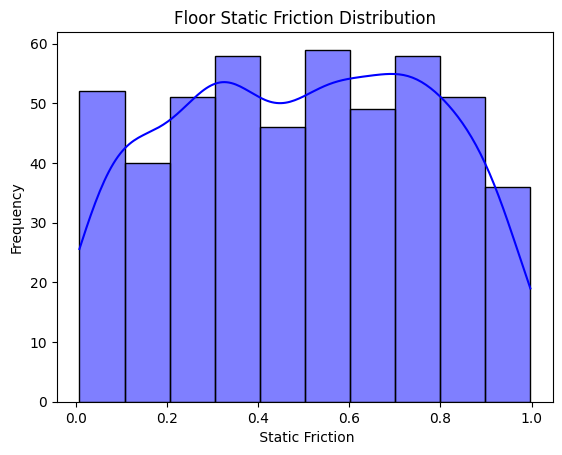

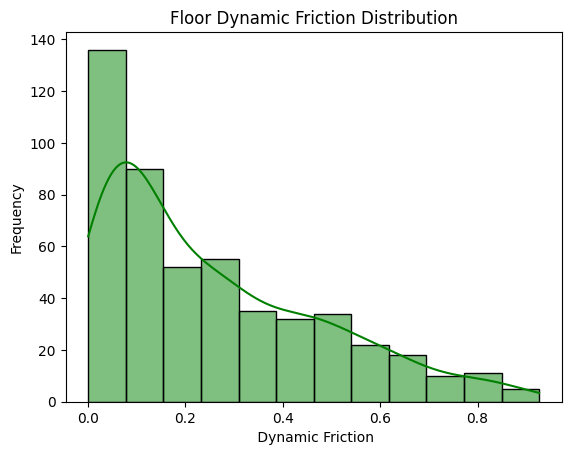

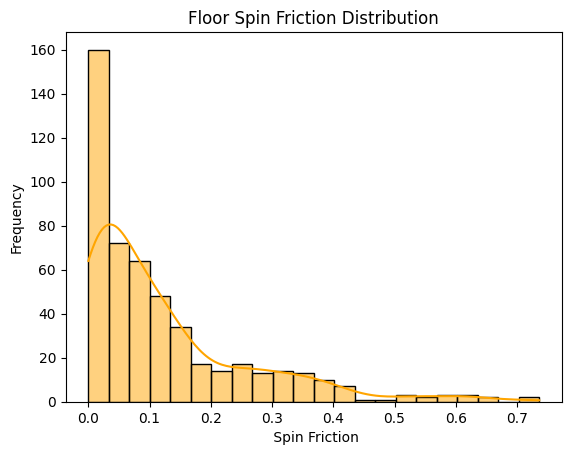

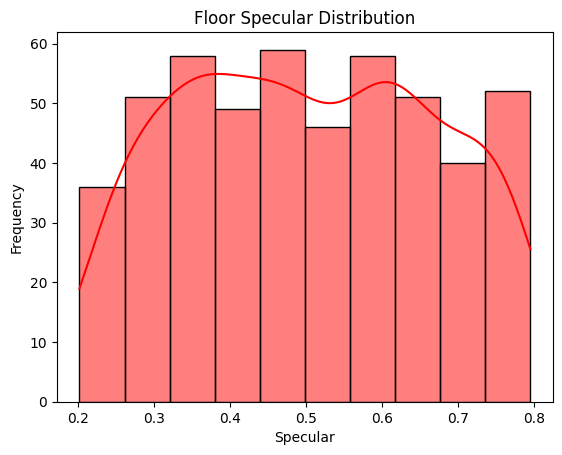

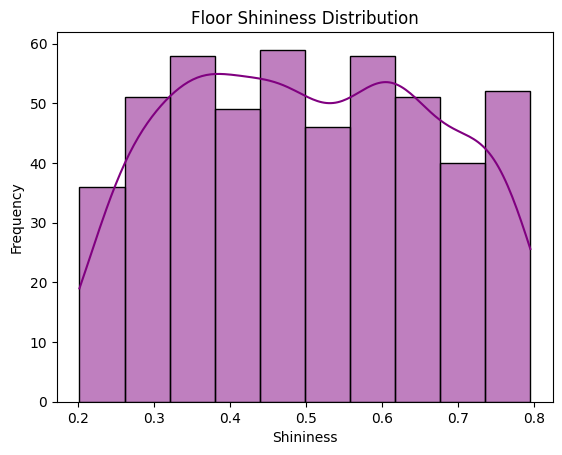

In [5]:
world_features = extract_world_features(data)

plot_distribution(world_features["friction_static"], "Floor Static Friction Distribution", "Frequency", " Static Friction")
plot_distribution(world_features["friction_dynamic"], "Floor Dynamic Friction Distribution", "Frequency", " Dynamic Friction")
plot_distribution(world_features["friction_spin"], "Floor Spin Friction Distribution", "Frequency", " Spin Friction")

plot_distribution(world_features["floor_speculars"], "Floor Specular Distribution", "Frequency", "Specular")
plot_distribution(world_features["floor_shininesses"], "Floor Shininess Distribution", "Frequency", "Shininess")



### Camera

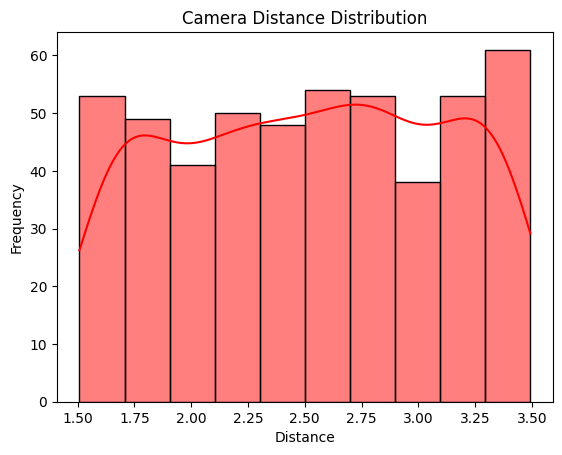

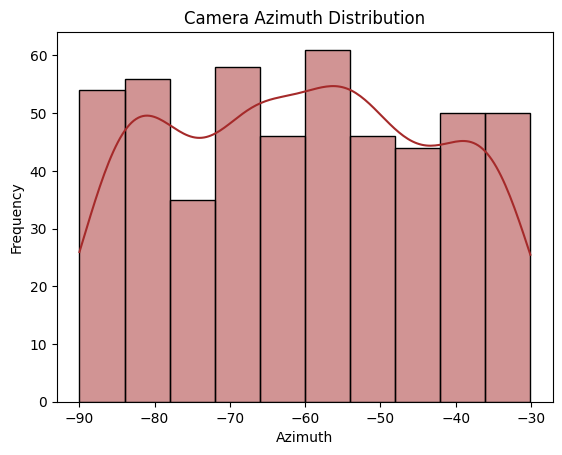

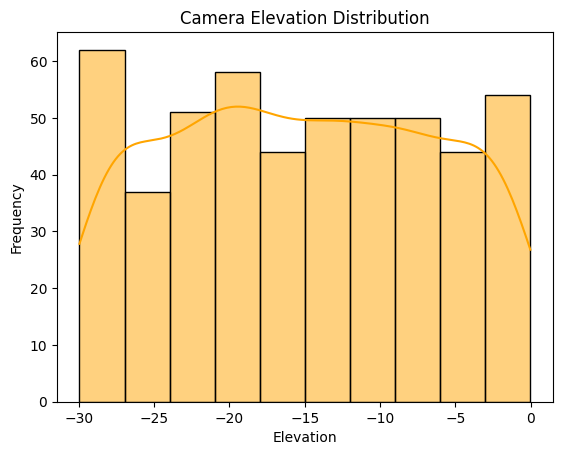

In [6]:

plot_distribution(world_features["camera_distance"], "Camera Distance Distribution", "Frequency", "Distance")
plot_distribution(world_features["camera_azimuth"], "Camera Azimuth Distribution", "Frequency", "Azimuth")
plot_distribution(world_features["camera_elevation"], "Camera Elevation Distribution", "Frequency", "Elevation")


### Lights 

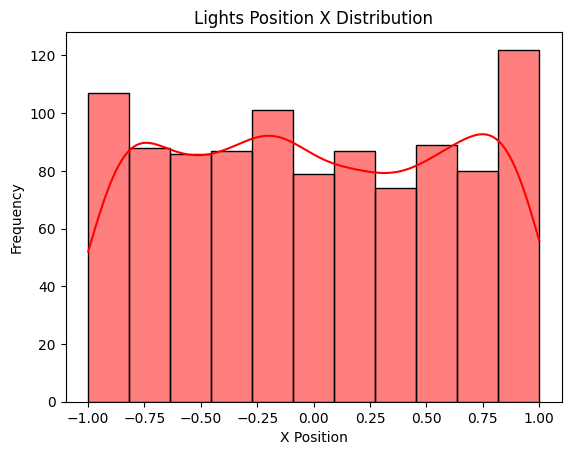

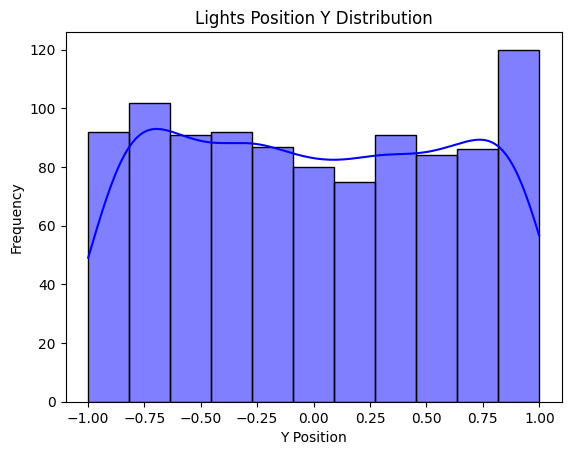

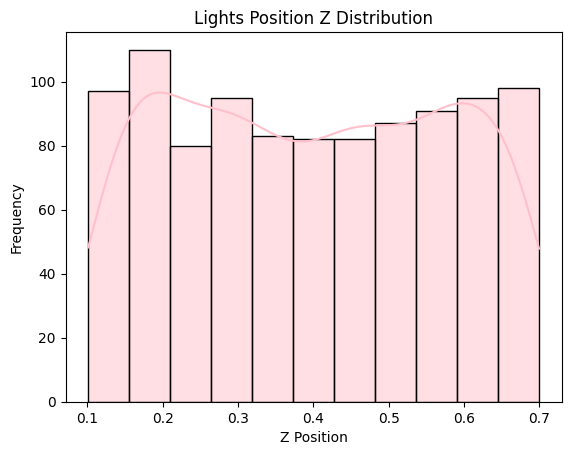

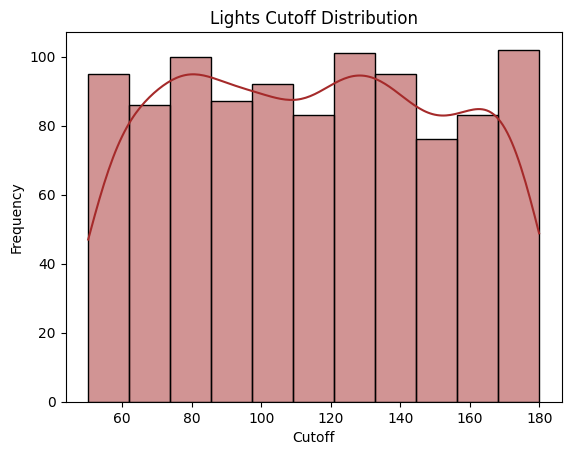

In [7]:
plot_distribution(world_features["lights_pos_x"], "Lights Position X Distribution", "Frequency", "X Position")
plot_distribution(world_features["lights_pos_y"], "Lights Position Y Distribution", "Frequency", "Y Position")
plot_distribution(world_features["lights_pos_z"], "Lights Position Z Distribution", "Frequency", "Z Position")
# plot_distribution(world_features["lights_diffuse_r"], "Lights Diffuse Red Distribution", "Frequency", "Diffuse R")
# plot_distribution(world_features["lights_diffuse_g"], "Lights Diffuse Green Distribution", "Frequency", "Diffuse G")
# plot_distribution(world_features["lights_diffuse_b"], "Lights Diffuse Blue Distribution", "Frequency", "Diffuse B")
# plot_distribution(world_features["lights_specular_r"], "Lights Specular Red Distribution", "Frequency", "Specular R")
# plot_distribution(world_features["lights_specular_g"], "Lights Specular Green Distribution", "Frequency", "Specular G")
# plot_distribution(world_features["lights_specular_b"], "Lights Specular Blue Distribution", "Frequency", "Specular B")
plot_distribution(world_features["lights_cutoff"], "Lights Cutoff Distribution", "Frequency", "Cutoff")
# plot_distribution(world_features["lights_directional"], "Lights Directional Distribution", "Frequency", "Directional")

### Elements

In [26]:
extracted_data = extract_features(data)
masses = extracted_data["masses"]
velocities = extracted_data["velocities"]
accelerations = extracted_data["accelerations"]
angular_velocities = extracted_data["angular_velocities"]

friction_static = extracted_data["friction_static"]
friction_dynamic = extracted_data["friction_dynamic"]
friction_spin = extracted_data["friction_spin"]

# frictions = extracted_data["frictions"]
densities = extracted_data["densities"]
elasticities = extracted_data["elasticities"]

shapes = extracted_data["shapes"]


In [9]:
# len(masses), len(velocities), len(accelerations), len(frictions), len(elasticities)

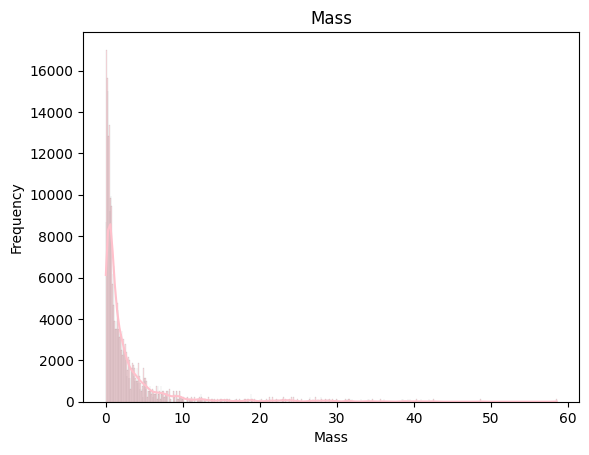

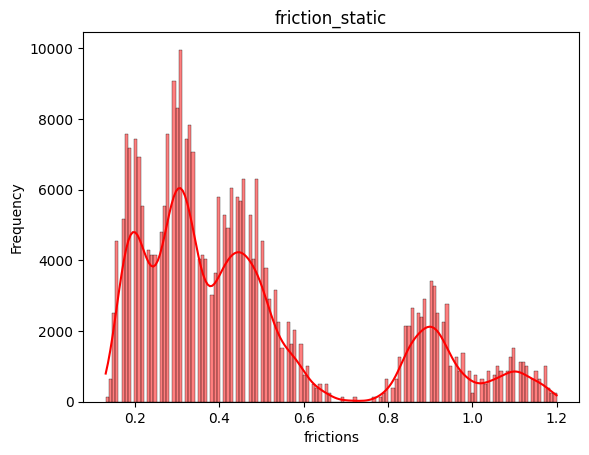

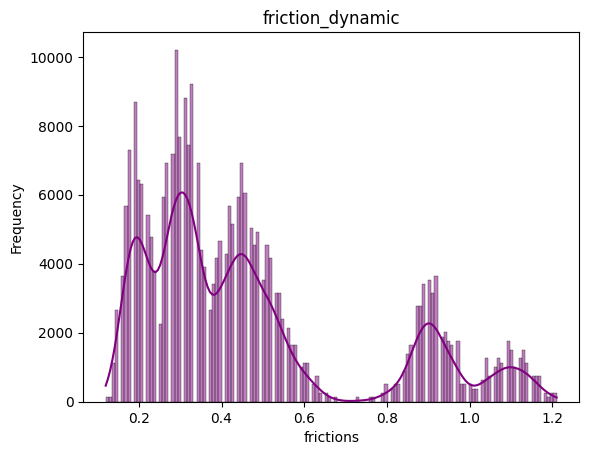

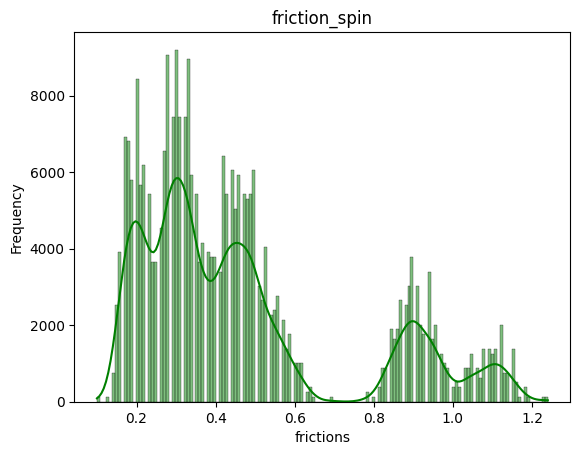

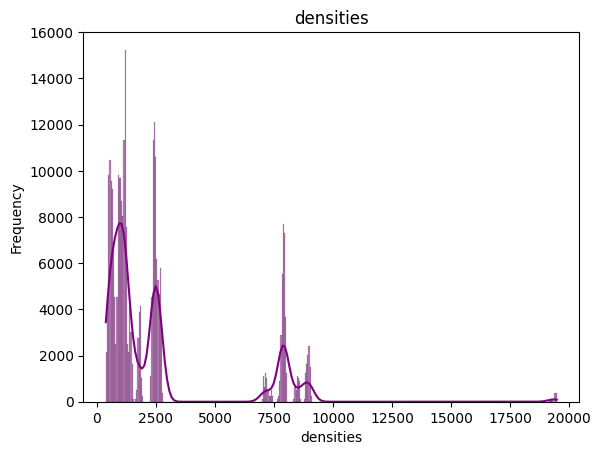

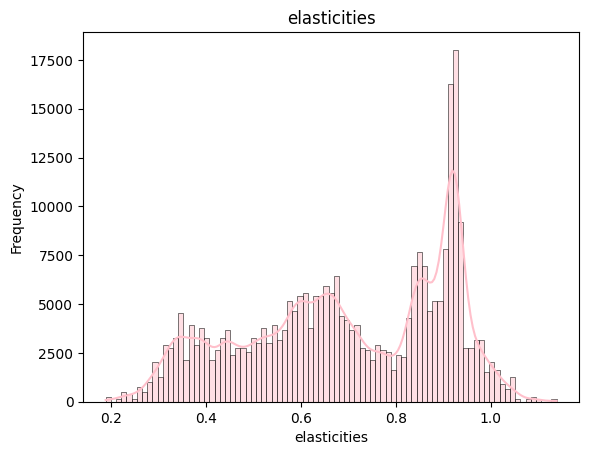

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_80453/3518492462.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="shape", data=df_shapes, palette="viridis")


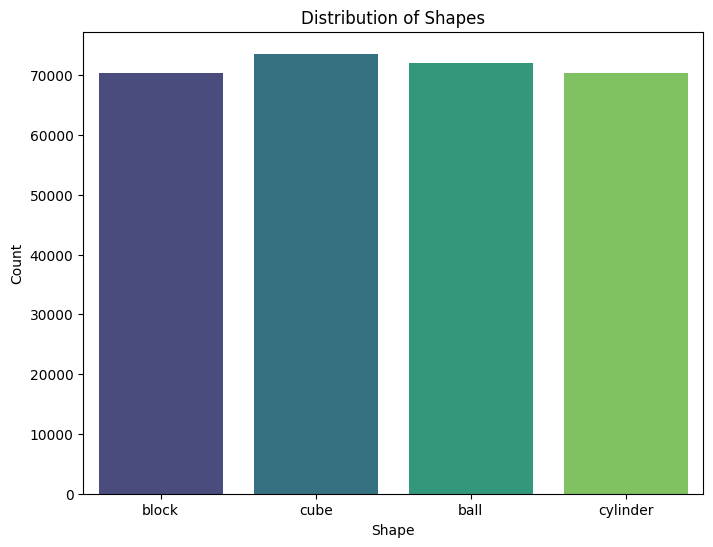

In [29]:
# plt.subplot(1, 2, 1)
plot_distribution(masses, "Mass", "Frequency", "Mass")
# plt.subplot(1, 2, 2)
# plt.tight_layout()
plot_distribution(friction_static, "friction_static", "Frequency", "frictions")
plot_distribution(friction_dynamic, "friction_dynamic", "Frequency", "frictions")
plot_distribution(friction_spin, "friction_spin", "Frequency", "frictions")
plot_distribution(densities, "densities", "Frequency", "densities")
plot_distribution(elasticities, "elasticities", "Frequency", "elasticities")
plot_shapes_distribution(shapes)


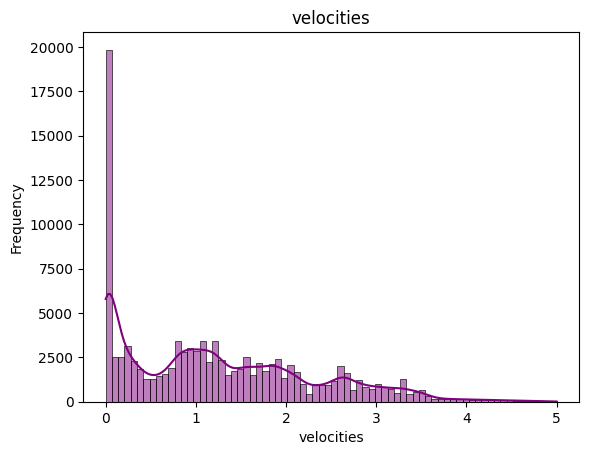

In [30]:
velocities_1 = list(filter(lambda v: round(v, 3) > 0, velocities))

plot_distribution(velocities_1, "velocities", "Frequency", "velocities")
# plot_distribution(accelerations, "accelerations", "Frequency", "accelerations", kde=False)

97107 4578


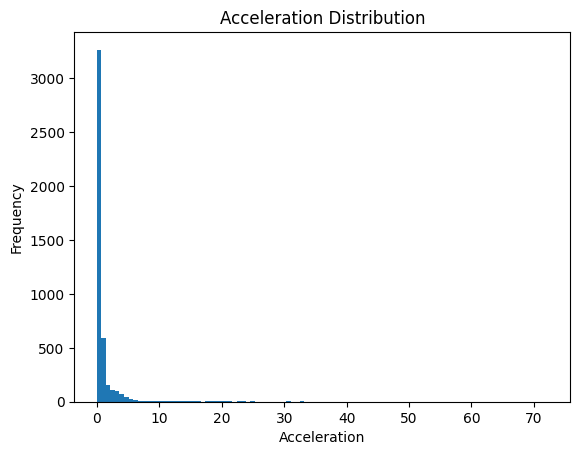

In [31]:
filtered_accelerations = [a for a in accelerations if  round(a, 3) > 0]
print(len(accelerations), len(filtered_accelerations))


plt.hist(filtered_accelerations, bins=100)
plt.title("Acceleration Distribution")
plt.xlabel("Acceleration")
plt.ylabel("Frequency")
plt.show()


In [32]:

def analyze_data(extracted_features, use_correlation=False, scale_data=False):
    # extracted_features = extract_features(input_data)

    data = {k: v for k, v in extracted_features.items() if v}
    # print(data)
    max_length = max(len(data[key]) for key in data)
    # print("max_length", max_length)
    # Pad shorter lists with NaN to match the maximum length
    for key in data:
        # print("key", key)
        # print(len(data[key]))
        # print(data[key][-10:])
        if len(data[key]) < max_length:
            # print(len(data[key]))
            # data[key].extend(data[key] * (max_length - len(data[key])))
            while len(data[key]) < max_length:
                data[key].append(np.nan)


    df = pd.DataFrame(data)
    df = df.dropna() 

    if scale_data:
        scaler = StandardScaler()
        df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns) # Scale data

    if use_correlation:
        matrix = df.corr(method='pearson') 
        title = 'Correlation Matrix of Physical Properties'
    else:
        matrix = df.cov()
        title = 'Covariance Matrix of Physical Properties'

    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(title)
    plt.show()



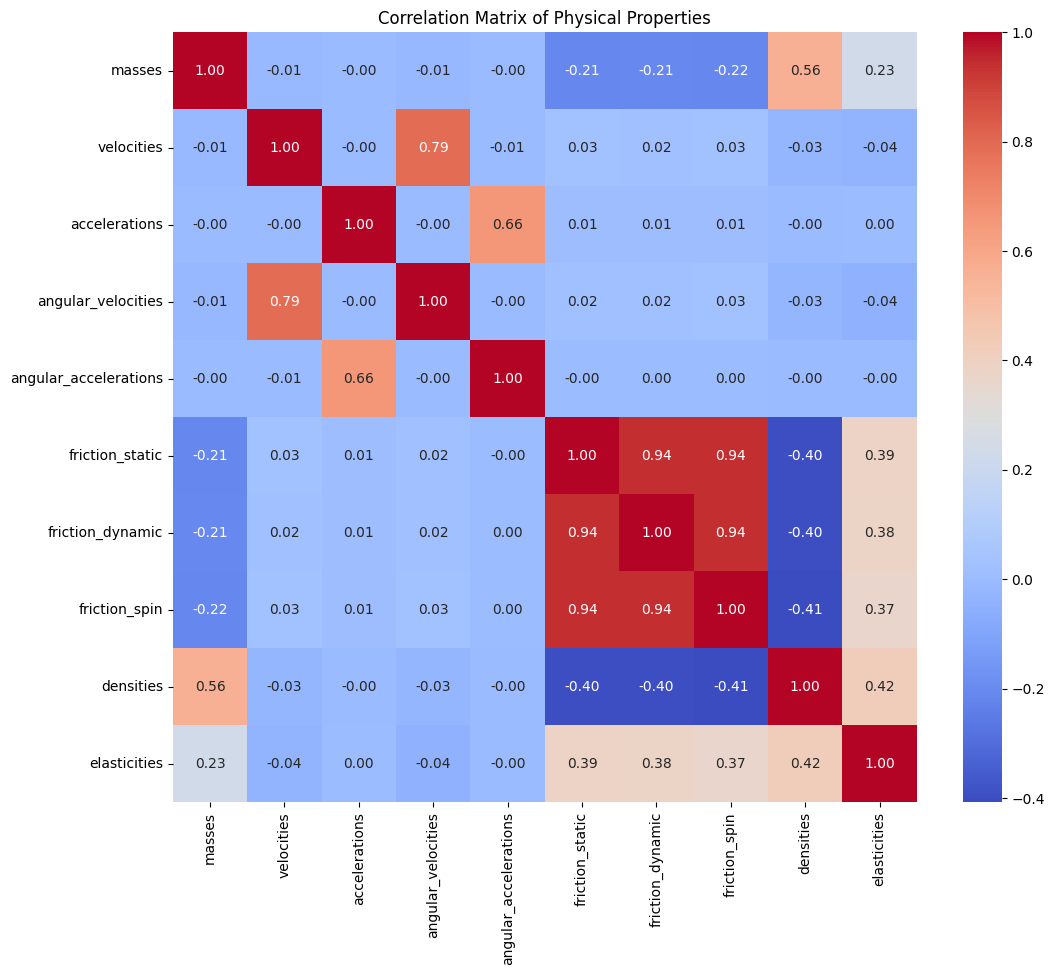

In [35]:
obj_features = extract_features(data)
del obj_features["shapes"]
world_features = extract_world_features(data)
analyze_data(obj_features, use_correlation=True, scale_data=True)  
# analyze_data(world_features, use_correlation=True, scale_data=True)  

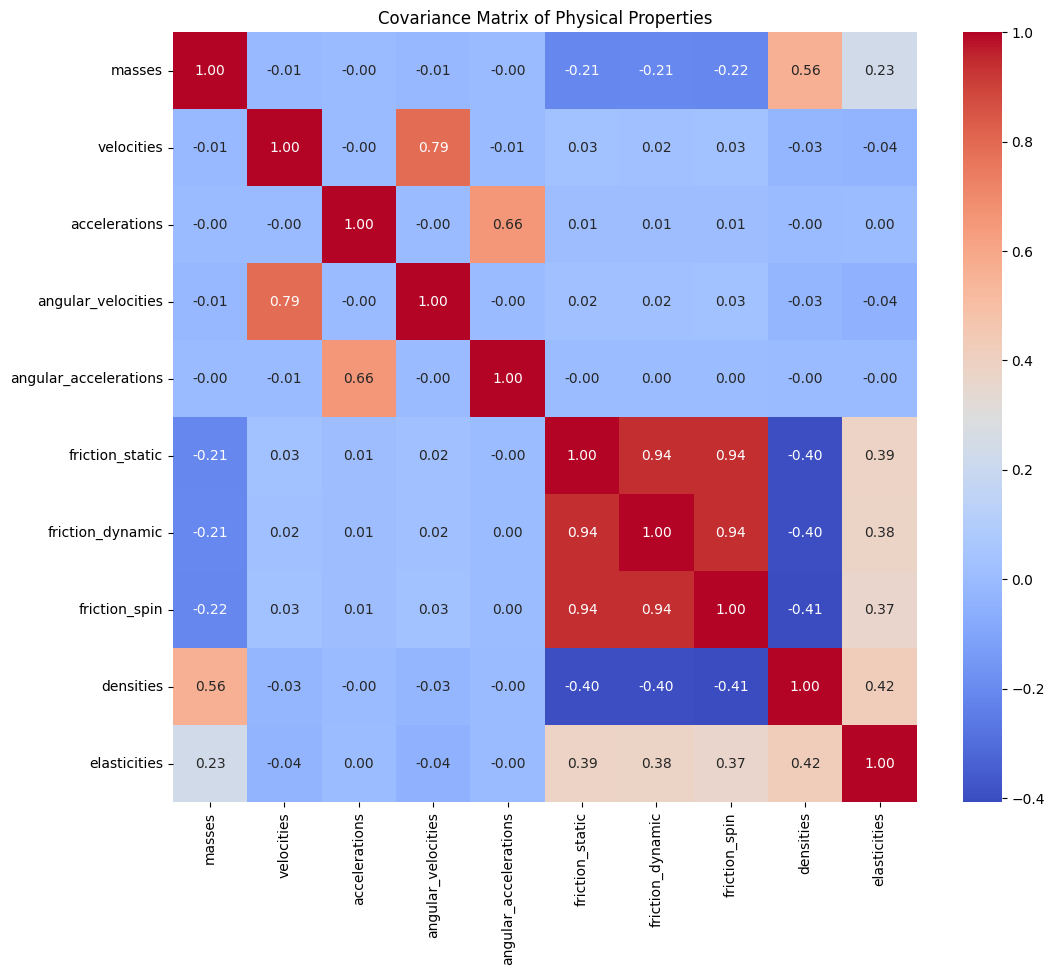

In [20]:
obj_features = extract_features(data)
analyze_data(obj_features, use_correlation=False, scale_data=True)  
